# HOMEWORK Week 4 period 1


1. **Bài 1**: Phân loại khả năng sống sót trên tập Titanic Dataset bằng Logistic Regression.
2. **Bài 2**: Phân loại loại hạt trên tập Dry Bean Dataset bằng Logistic Regression và KNN.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## BÀI 1: TITANIC DATASET
- Sử dụng Logistic Regression.
- So sánh và đưa ra nhận xét so với Linear Regression.

In [2]:
# 1. Đọc dữ liệu
train_df = pd.read_csv('train.csv')

# 2. Tiền xử lý dữ liệu
# Xử lý missing values
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Xóa các cột không mang nhiều thông tin phân loại
train_df = train_df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])

# Label Encoding cho giới tính
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})

# One-hot Encoding cho Embarked
train_df = pd.get_dummies(train_df, columns=['Embarked'], drop_first=True, dtype=int)

# Xác định Features (X) và Target (y)
X_titanic = train_df.drop(columns=['Survived'])
y_titanic = train_df['Survived']

# Chia dữ liệu train/test (tỉ lệ 80/20) đảm bảo phân phối mẫu cân bằng với stratify
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42, stratify=y_titanic
)

print("Kích thước tập Train (Titanic):", X_train_t.shape)
print("Kích thước tập Test (Titanic):", X_test_t.shape)

Kích thước tập Train (Titanic): (712, 8)
Kích thước tập Test (Titanic): (179, 8)


--- ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION ---
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-score : 0.7244


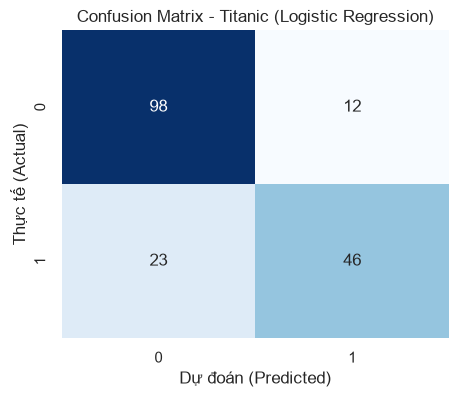

In [3]:
# 3. Xây dựng và đánh giá mô hình Logistic Regression
log_reg_titanic = LogisticRegression(max_iter=1000)
log_reg_titanic.fit(X_train_t, y_train_t)

# Dự đoán trên tập test
y_pred_t = log_reg_titanic.predict(X_test_t)

# Đánh giá
acc_t = accuracy_score(y_test_t, y_pred_t)
prec_t = precision_score(y_test_t, y_pred_t)
rec_t = recall_score(y_test_t, y_pred_t)
f1_t = f1_score(y_test_t, y_pred_t)
cm_t = confusion_matrix(y_test_t, y_pred_t)

print("--- ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION ---")
print(f"Accuracy : {acc_t:.4f}")
print(f"Precision: {prec_t:.4f}")
print(f"Recall   : {rec_t:.4f}")
print(f"F1-score : {f1_t:.4f}")

# Vẽ Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_t, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Titanic (Logistic Regression)")
plt.xlabel("Dự đoán (Predicted)")
plt.ylabel("Thực tế (Actual)")
plt.show()

### Nhận xét & So sánh với Linear Regression

1. **Bản chất thuật toán**: 
   - **Linear Regression** đưa ra các dự đoán mang giá trị số liên tục, giá trị này có thể vượt quá khoảng $[0, 1]$ hoặc thậm chí nhỏ hơn $0$. Nó bị ảnh hưởng rất mạnh bởi các điểm dữ liệu nhiễu (outliers).
   - **Logistic Regression** đưa đầu ra đi qua hàm Sigmoid, giúp ép mọi dự đoán về khoảng xác suất nằm trong đoạn $[0, 1]$. Điều này là phù hợp và tối ưu đối với bài toán phân loại phân phối nhị phân.
2. **Ngưỡng quyết định (Threshold)**:
   - Bằng việc dùng Logistic Regression, ta có thể dễ dàng thiết lập ngưỡng quyết định tự nhiên (thường là $0.5$) để phân lớp là sống ($1$) hay chết ($0$). Từ đó ta có thể dễ dàng tính toán được các chỉ số Classification chuẩn mực như Confusion Matrix, F1-score, Precision và Recall.
   - Linear Regression hoàn toàn không cung cấp cơ chế phân loại bằng ngưỡng xác suất tốt.
   
> **Kết luận**: Đối với bài toán phân loại hành khách (Survived: 1 hoặc 0), **Logistic Regression** là mô hình hợp lý, chuẩn xác và mang lại hiệu quả vượt trội hơn hẳn so với Linear Regression.

---
## BÀI 2: DRY BEAN DATASET
- Sử dụng Logistic Regression
- Sử dụng K-Nearest Neighbors (KNN)

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Đọc trực tiếp dữ liệu đã được tiền xử lý và chia sẵn từ processing_seeds.ipynb
train_bean = pd.read_csv(r"C:\Users\Vinh\Desktop\mliot-pyml-2026-hw\week04\Homework_b7\dry_bean_train.csv")
test_bean = pd.read_csv(r"C:\Users\Vinh\Desktop\mliot-pyml-2026-hw\week04\Homework_b7\dry_bean_test.csv")

# 2. Tách features (X) và target (y)
X_train_b = train_bean.drop(columns=['class'])
y_train_b = train_bean['class']

X_test_b = test_bean.drop(columns=['class'])
y_test_b = test_bean['class']

# 3. Chuẩn hóa dữ liệu bằng StandardScaler
# Lưu ý: Fit trên tập Train, chỉ Transform trên tập Test để tránh bị hiện tượng rò rỉ dữ liệu (Data Leakage)
scaler = StandardScaler()
X_train_b_scaled = scaler.fit_transform(X_train_b)
X_test_b_scaled = scaler.transform(X_test_b)  

print("Kích thước tập Train (Dry Bean):", X_train_b_scaled.shape)
print("Kích thước tập Test (Dry Bean):", X_test_b_scaled.shape)

Kích thước tập Train (Dry Bean): (10834, 16)
Kích thước tập Test (Dry Bean): (2709, 16)


In [5]:
# 2. Thuật toán Logistic Regression
print("="*60)
print("MÔ HÌNH 1: LOGISTIC REGRESSION (DRY BEAN)")
print("="*60)

log_reg_bean = LogisticRegression(max_iter=2000)
log_reg_bean.fit(X_train_b_scaled, y_train_b)

y_pred_b_lr = log_reg_bean.predict(X_test_b_scaled)

print(f"Accuracy: {accuracy_score(y_test_b, y_pred_b_lr):.4f}\n")
print("Classification Report:")
print(classification_report(y_test_b, y_pred_b_lr))

MÔ HÌNH 1: LOGISTIC REGRESSION (DRY BEAN)


Accuracy: 0.9192

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



In [6]:
# 3. Thuật toán K-Nearest Neighbors (KNN)
print("="*60)
print("MÔ HÌNH 2: K-NEAREST NEIGHBORS (DRY BEAN)")
print("="*60)

# Khởi tạo KNN với K = 5
knn_bean = KNeighborsClassifier(n_neighbors=5)
knn_bean.fit(X_train_b_scaled, y_train_b)

y_pred_b_knn = knn_bean.predict(X_test_b_scaled)

print(f"Accuracy: {accuracy_score(y_test_b, y_pred_b_knn):.4f}\n")
print("Classification Report:")
print(classification_report(y_test_b, y_pred_b_knn))

MÔ HÌNH 2: K-NEAREST NEIGHBORS (DRY BEAN)
Accuracy: 0.9155

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.88      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.92       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.95      0.94      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709

